## 1. Load OASIS Longitudinal Dataset


In [ ]:
import pandas as pd

# load the Excel file
df = pd.read_excel("oasis_longitudinal.xlsx")

# preview first few rows
df.head()


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1986.550000,0.696106,0.883440
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004.479526,0.681062,0.875539
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678.290000,0.736336,1.045710
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1737.620000,0.713402,1.010000
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1697.911134,0.701236,1.033623


## 2. Assess Missing Clinical Values


In [ ]:
df.isnull().sum()


,0
Subject ID,0
MRI ID,0
Group,0
Visit,0
MR Delay,0
M/F,0
Hand,0
Age,0
EDUC,0
SES,19


## 3. Remove Records Without Cognitive Scores



In [ ]:
df_clean = df.dropna(subset=['MMSE'])


In [ ]:
print(f"Number of patient records after cleaning: {df_clean.shape[0]}")


Number of patient records after cleaning: 371


### Exclude Socioeconomic Feature to Reduce Bias


In [ ]:
df_clean = df_clean.drop(columns=['SES'])


## 4. Encode Clinical Labels and Demographic Covariates



In [ ]:
# Encode diagnosis group
df_clean['Group'] = df_clean['Group'].map({
    'Nondemented': 0,
    'Demented': 1,
    'Converted': 1
})

# Encode gender
df_clean['M/F'] = df_clean['M/F'].map({
    'M': 1,
    'F': 0
})

# Encode handedness
df_clean['Hand'] = df_clean['Hand'].map({
    'R': 1,
    'L': 0
})


## 5. Remove Identifiers and Non-Predictive Fields


In [ ]:
df_clean = df_clean.drop(columns=['Subject ID', 'MRI ID'])


## 6. Compute Age-Adjusted Brain Atrophy Score
Raw brain volume naturally decreases with age, which can confound dementia risk estimation.
To isolate disease-related neurodegeneration, we first learn the expected brain volume for a given age using a linear regression model.
We then compute an age-adjusted atrophy score as the deviation between a patient’s observed brain volume and the age-expected value.
This score captures abnormal atrophy beyond normal aging and is used as a clinically meaningful feature for downstream risk prediction.

###  The age-based reference trend is estimated from the cohort due to dataset size constraints, and deviations from this trend are used to capture relative abnormal atrophy rather than absolute normative aging.

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Fit regression: Age -> nWBV
X = df_clean[['Age']]
y = df_clean['nWBV']

age_model = LinearRegression()
age_model.fit(X, y)

# 2. Expected brain volume for each age
df_clean['expected_nWBV'] = age_model.predict(X)

# 3. Atrophy score (actual - expected)
df_clean['atrophy_score'] = df_clean['nWBV'] - df_clean['expected_nWBV']


### Progression Modeling (Future Extension)

This prototype focuses on cross-sectional Alzheimer’s risk stratification, identifying whether a patient’s brain volume is abnormally low for their age.

However, the proposed age-adjusted brain atrophy score is explicitly designed to support longitudinal disease monitoring. In a longitudinal setting with multiple visits per patient, disease progression can be quantified as the change in atrophy score between visits.

Because the atrophy score is normalized for age, it remains comparable across visits, making it suitable for tracking disease progression over time without retraining the core model.

## Final Feature Set for Risk Prediction


In [ ]:
# Lock final features for AI
df_final = df_clean.drop(columns=['expected_nWBV'], errors='ignore')

In [ ]:
df_final["cognitive_reserve_index"] = df_final["EDUC"] / (df_final["atrophy_score"] + 1e-3)


## Feature Scaling and Label Definition


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and label
X = df_final.drop(columns=['Group'])
y = df_final['Group']

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Back to DataFrame (keeps column names)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


##Baseline Dementia Risk Prediction (Probability Estimation)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.90      1.00      0.95        38
           1       1.00      0.89      0.94        37

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75

ROC-AUC: 0.9722617354196302


In [ ]:
feature_weights = pd.Series(
    model.coef_[0],
    index=X_scaled.columns
).sort_values(key=abs, ascending=False)

feature_weights


,0
CDR,6.514483
MMSE,-2.229825
atrophy_score,-1.102637
EDUC,-0.904889
eTIV,-0.833351
nWBV,-0.785261
M/F,0.673754
ASF,0.546798
Visit,-0.512728
MR Delay,-0.241800


## Explicit Uncertainty Handling via Risk Bands


In [ ]:
# --- Explicit Uncertainty Handling via Risk Bands ---

import numpy as np
import pandas as pd

# Get predicted probabilities for the positive class
y_proba = model.predict_proba(X_test)[:, 1]

# Define uncertainty-aware risk bands
def risk_band(p):
    if p < 0.35:
        return "Low Risk (Confident)"
    elif p > 0.65:
        return "High Risk (Confident)"
    else:
        return "Uncertain / Needs Monitoring"

risk_df = pd.DataFrame({
    "True Label": y_test.values,
    "Predicted Probability": y_proba,
    "Risk Band": [risk_band(p) for p in y_proba]
})

# Show distribution of uncertainty
risk_df["Risk Band"].value_counts()


,count
Risk Band,
Low Risk (Confident),37
High Risk (Confident),28
Uncertain / Needs Monitoring,10


In [ ]:
df_final["risk_probability"] = model.predict_proba(X_scaled)[:, 1]
df_final["risk_band"] = df_final["risk_probability"].apply(risk_band)


## Patient-Level Risk Explanation: Why THIS Patient Is at Risk


In [ ]:
# Patient-level explanation for an individual test case


import pandas as pd

# Select one representative test patient for explanation
patient_idx = 0

# Extract patient data
patient_features = X_test.iloc[patient_idx]
patient_probability = y_proba[patient_idx]
patient_risk = risk_band(patient_probability)

# Compute feature-wise contribution to THIS patient's risk (linear model logic)
contributions = patient_features.values * model.coef_[0]

patient_explanation = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Feature Value (Scaled)": patient_features.values,
    "Contribution to Risk": contributions
}).sort_values(by="Contribution to Risk", key=abs, ascending=False)

print(" Patient-Level Risk Explanation ")
print(f"Predicted Dementia Risk Probability: {patient_probability:.2f}")
print(f"Risk Category: {patient_risk}")
print("\nTop factors influencing this prediction:\n")

patient_explanation.head(6)


 Patient-Level Risk Explanation 
Predicted Dementia Risk Probability: 1.00
Risk Category: High Risk (Confident)

Top factors influencing this prediction:



,Feature,Feature Value (Scaled),Contribution to Risk
7,CDR,1.000000,6.514483
6,MMSE,0.653846,-1.457962
5,EDUC,0.647059,-0.585516
11,atrophy_score,0.392001,-0.432235
8,eTIV,0.441891,-0.368250
10,ASF,0.410607,0.224519


## Clinically Interpretable Risk Landscape (Cognition vs Brain Atrophy)


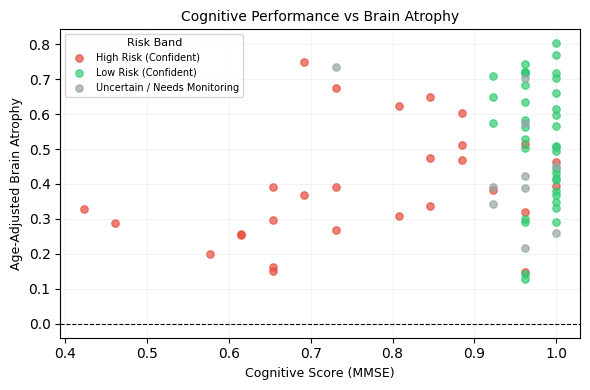

In [ ]:
import matplotlib.pyplot as plt

# Build visualization dataframe from TEST SET ONLY
viz_df = X_test.copy()
viz_df["Predicted Probability"] = y_proba
viz_df["Risk Band"] = [risk_band(p) for p in y_proba]

# Color mapping
color_map = {
    "High Risk (Confident)": "#e74c3c",
    "Low Risk (Confident)": "#2ecc71",
    "Uncertain / Needs Monitoring": "#95a5a6"
}

# SMALLER figure (fits Colab window)
plt.figure(figsize=(6, 4))

for band, color in color_map.items():
    subset = viz_df[viz_df["Risk Band"] == band]
    plt.scatter(
        subset["MMSE"],
        subset["atrophy_score"],
        c=color,
        label=band,
        alpha=0.7,
        s=28
    )

# Normal aging reference
plt.axhline(0, linestyle="--", color="black", linewidth=0.8)

plt.xlabel("Cognitive Score (MMSE)", fontsize=9)
plt.ylabel("Age-Adjusted Brain Atrophy", fontsize=9)
plt.title("Cognitive Performance vs Brain Atrophy", fontsize=10)

plt.legend(fontsize=7, title="Risk Band", title_fontsize=8)
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()


## Population-Level Safety Analysis Using Risk Bands


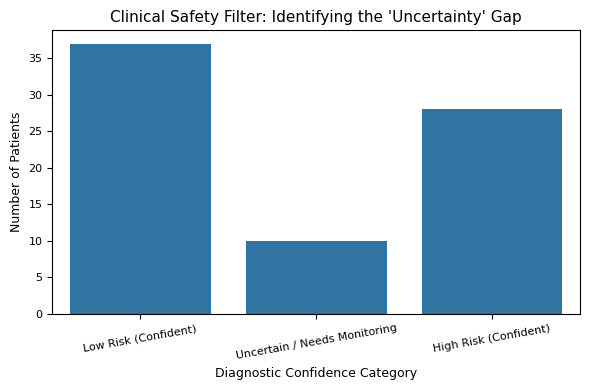

Total Uncertain Cases flagged for Physician Review: 10


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize the Risk Bands (smaller & compact)
plt.figure(figsize=(6, 4))

sns.countplot(
    x='Risk Band',
    data=risk_df,
    order=[
        "Low Risk (Confident)",
        "Uncertain / Needs Monitoring",
        "High Risk (Confident)"
    ]
)

plt.title(
    "Clinical Safety Filter: Identifying the 'Uncertainty' Gap",
    fontsize=11
)
plt.ylabel("Number of Patients", fontsize=9)
plt.xlabel("Diagnostic Confidence Category", fontsize=9)

plt.xticks(fontsize=8, rotation=10)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

# 2. Quantify cases flagged for physician review due to uncertainty
uncertain_cases = risk_df[risk_df['Risk Band'] == "Uncertain / Needs Monitoring"]
print(f"Total Uncertain Cases flagged for Physician Review: {len(uncertain_cases)}")


## Global Feature Influence (Model Context Only)


In [ ]:
import pandas as pd

feature_importance = pd.Series(
    model.coef_[0],
    index=X_scaled.columns
).sort_values(key=abs, ascending=False)

feature_importance


,0
CDR,6.514483
MMSE,-2.229825
atrophy_score,-1.102637
EDUC,-0.904889
eTIV,-0.833351
nWBV,-0.785261
M/F,0.673754
ASF,0.546798
Visit,-0.512728
MR Delay,-0.241800
